## Задание 1 (0.5 балла)



Найдите экстремумы следующих функций (вручную, где возможно) и укажите их тип (максимум, минимум):

a) $f(x) = x^2 - 30x + 1$

b) $g(x) = -x^3 + 5x - 7x^2 + 17$

c) $h(x) = x^2 - 1/x$

d) $j(x) = 1/x^5 + x^{17} + 8$

## Задание 2 (1 балл)

Найдите экстремумы этих функций в Python.

In [ ]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
def get_extremym(f):
  x = sp.Symbol('x')
  f_x = sp.diff(f, x)
  critic_dots = sp.solve(f_x, x)
  real_critic_dots = [dot for dot in critic_dots if sp.im(dot) == 0]
  f_x2 = sp.diff(f_x, x)
  for num in real_critic_dots:
    a = f_x2.subs(x, num)
    if a > 0:
      return f'Критические точки: {real_critic_dots}, {num} - точка минимума'
    elif a < 0:
      return f'Критические точки: {real_critic_dots}, {num} - точка максимума'
    else:
      return f'Критические точки: {real_critic_dots}, {num} - седло'



In [ ]:
x = sp.Symbol('x')
get_extremym(x**2 - 30*x + 1)

'Критические точки: [15], 15 - точка минимума'

In [ ]:
x = sp.Symbol('x')
get_extremym(-x**3 + 5*x - 7*x**2 + 17)

'Критические точки: [-5, 1/3], -5 - точка минимума'

In [ ]:
x = sp.Symbol('x')
get_extremym(x**2 - 1/x)

'Критические точки: [-2**(2/3)/2], -2**(2/3)/2 - точка минимума'

In [ ]:
x = sp.Symbol('x')
get_extremym(1/x**5 + x**17 + 8)

'Критические точки: [-17**(21/22)*5**(1/22)/17, 17**(21/22)*5**(1/22)/17], -17**(21/22)*5**(1/22)/17 - точка максимума'

## Задание 3 (1 балл)

Найдите точки перегиба функций из задания 1 (вручную, где возможно).

## Задание 4 (1 балла)

Найдите точки перегиба этих функций в Python.

In [ ]:
def get_inflection_dots(f):
  x = sp.Symbol('x')
  f_x2 = sp.diff(f, x, 2)
  a = sp.solve(f_x2, x)
  roots = [dot for dot in a if sp.im(dot) == 0]
  dots = []
  for num in roots:
    left = f_x2.subs(x, num - 0.1)
    right = f_x2.subs(x, num + 0.1)
    if (left > 0 and right < 0) or (left < 0 and right > 0):
      dots.append(num)
  if dots:
    return f'Точки перегиба {dots}'
  else:
    return 'Точек перегиба нет'

In [ ]:
x = sp.Symbol('x')
get_inflection_dots(x**2 - 30*x + 1)

'Точек перегиба нет'

In [ ]:
x = sp.Symbol('x')
get_inflection_dots(-x**3 + 5*x - 7*x**2 + 17)

'Точки перегиба [-7/3]'

In [ ]:
x = sp.Symbol('x')
get_inflection_dots(x**2 - 1/x)

'Точки перегиба [1]'

In [ ]:
x = sp.Symbol('x')
get_inflection_dots(1/x**5 + x**17 + 8)

'Точек перегиба нет'

### Внимание! Далее все задания необходимо выполнять для ВСЕХ функций из задания 1!

## Задание 5 (1 балл)

Постройте графики функций из задания 1 в Python (не забудьте подписать оси и сами графики):
*   изобразите графики с подписанными осями
*   отметьте одним цветом локальные экстремумы
*   отметьте другим цветом точки перегиба
*   подпишите на оси x значения экстремумов и точек перегиба

P.S. Для того, чтобы отметить точку на графике, вам понадобится функция (plt.scatter), а для того, чтобы подписать её значение на оси (plt.annotate).

Пример хорошего графика:

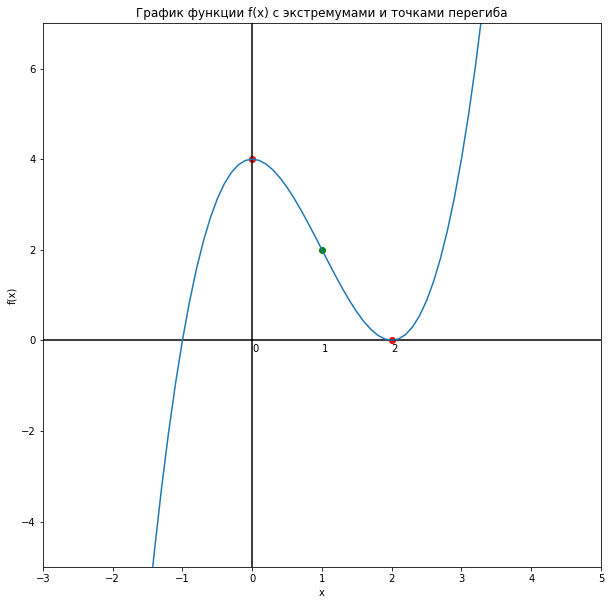

In [ ]:
# немного изменим функции для графиков
def get_extremym_for_plot(f):
  x = sp.Symbol('x')
  f_x = sp.diff(f, x)
  critic_dots = sp.solve(f_x, x)
  real_critic_dots = [dot for dot in critic_dots if sp.im(dot) == 0]
  return real_critic_dots

def get_inflection_dots_for_plot(f):
  x = sp.Symbol('x')
  f_x2 = sp.diff(f, x, 2)
  a = sp.solve(f_x2, x)
  roots = [dot for dot in a if sp.im(dot) == 0]
  dots = []
  for num in roots:
    left = f_x2.subs(x, num - 0.1)
    right = f_x2.subs(x, num + 0.1)
    if (left > 0 and right < 0) or (left < 0 and right > 0):
      dots.append(num)
  if dots:
    return dots

In [ ]:
get_extremym_for_plot(-x**3 + 5*x - 7*x**2 + 17)

[-5, 1/3]

In [ ]:
def get_graph(f, rang):
  x = sp.Symbol('x')
  f_num = sp.lambdify(x, f, 'numpy')
  x_values = np.linspace(*rang, 1000)
  x_values = x_values[x_values != 0]
  f_values = f_num(x_values)
  critical_dots = get_extremym_for_plot(f)
  if get_inflection_dots_for_plot(f):
      inflect_dots = get_inflection_dots_for_plot(f)
  else:
    inflect_dots = False
  crit_x = np.array([float(pt) for pt in critical_dots if rang[0] < pt < rang[1]])
  crit_y = f_num(crit_x)
  if inflect_dots:
    inflect_x = np.array([float(pt) for pt in inflect_dots if rang[0] < pt < rang[1]])
    inflect_y = f_num(inflect_x)
  plt.figure(figsize=(12, 8))
  plt.plot(x_values, f_values, label=f)
  plt.scatter(crit_x, crit_y, color='red', label='Экстремумы', zorder=5)
  if inflect_dots:
    plt.scatter(inflect_x, inflect_y, color='yellow', label='Точки перегиба', zorder=5)
  plt.axvline(x=0, c='black')
  plt.axhline(y=0, c='black')
  for (cx, cy) in zip(crit_x, crit_y):
    plt.annotate(
        f'{cx:.2f}',
        (cx, cy),
        textcoords="offset points",
        xytext=(-10, 10),
        ha='center',
        color='red', fontsize=10
    )
  if inflect_dots:
    for (ix, iy) in zip(inflect_x, inflect_y):
        plt.annotate(
            f'{ix:.2f}',
            (ix, iy),
            textcoords="offset points",
            xytext=(10, -10),
            ha='center',
            color='green', fontsize=10
    )
  plt.title(f'График функции {f} с экстремумами и точками перегиба')
  plt.xlabel('x')
  plt.ylabel('f(x)')
  plt.legend()
#  plt.xlim([-3, 5])
#  plt.ylim([-5, 7])
  plt.show()

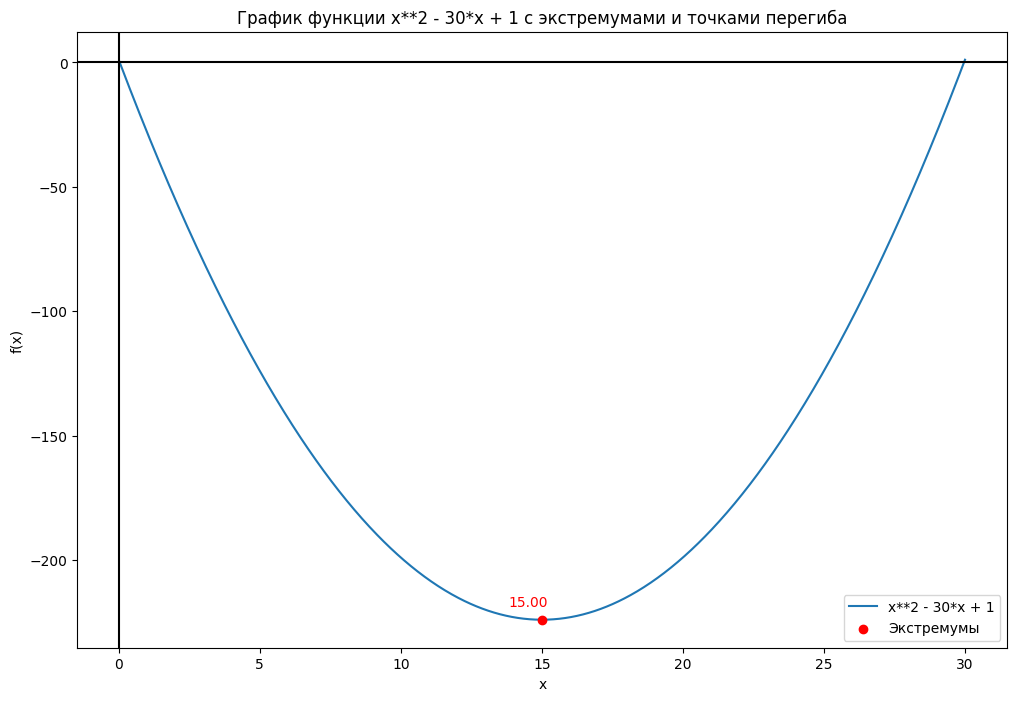

In [ ]:
x = sp.Symbol('x')
get_graph(x**2 - 30*x + 1, (0, 30))

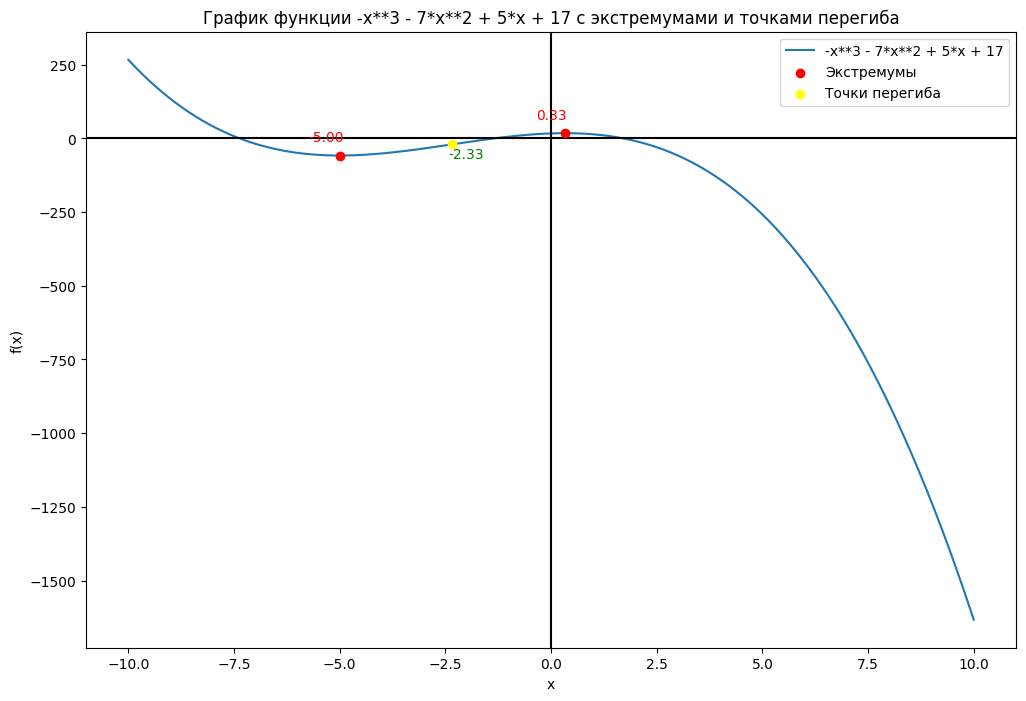

In [ ]:
x = sp.Symbol('x')
get_graph(-x**3 + 5*x - 7*x**2 + 17, (-10, 10))

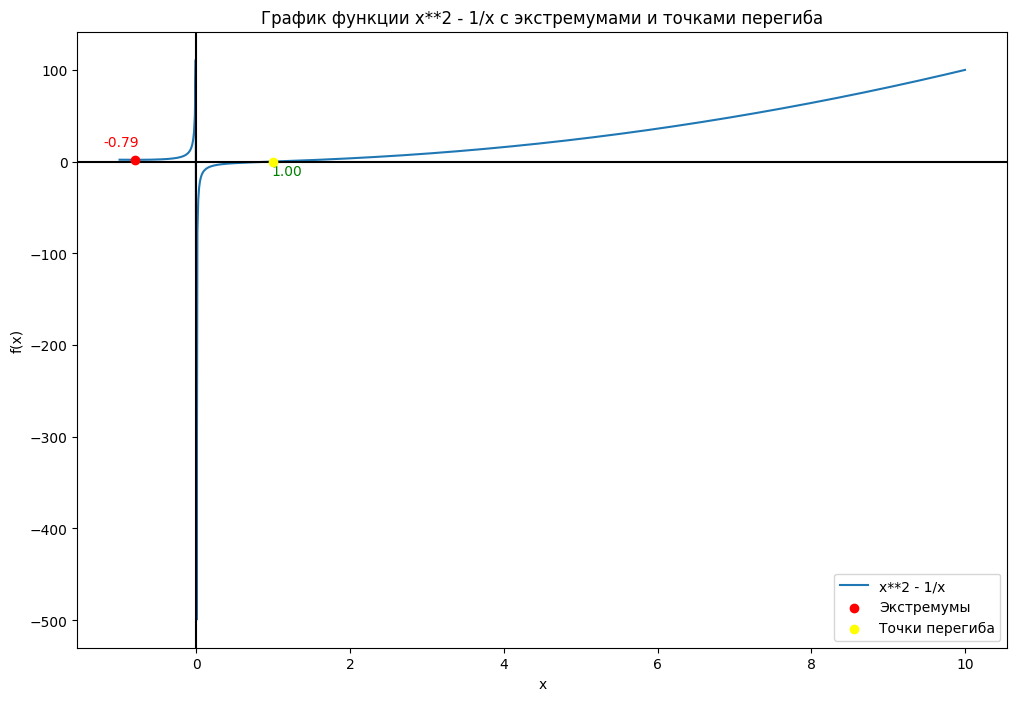

In [ ]:
x = sp.Symbol('x')
get_graph(x**2 - 1/x, (-1, 10))

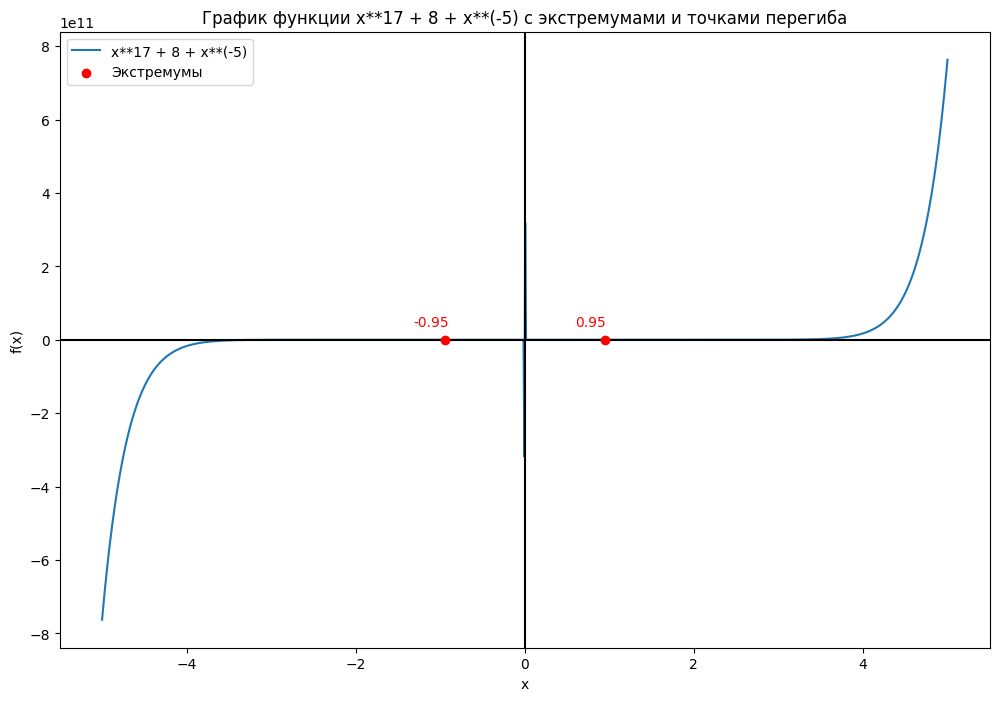

In [ ]:
x = sp.Symbol('x')
get_graph(1/x**5 + x**17 + 8, (-5, 5))

## Задание 6 (1 балл)

Модифицируйте функцию, осуществляющую метод градиентного спуска с семинара: добавьте опцию останавливать метод, если абсолютное значение производной функции в точке < некоторого $\delta$ (delta добавьте в аргументы функции).

In [ ]:
def gradient_descent(f, x, x_start, learning_rate, epsilon, num_iterations, delta):
    x_curr = x_start
    df_x = sp.diff(f, x) # производная

    trace = []
    trace.append(x_curr)

    for i in range(num_iterations):
      value = df_x.subs(x, x_curr)
      if abs(value) < delta:
        return x_curr, trace

      x_new = x_curr - learning_rate * df_x.subs(x, x_curr)
      trace.append(x_new)

      if abs(x_new - x_curr) < epsilon:
        return x_curr, trace

      x_curr = x_new

    return x_curr, trace

## Задание 7 (1 балл)

Подберите начальное приближение (сделайте несколько запусков из случайной начальной точки) и шаг градиентного спуска таким образом, чтобы процедура выдавала правильное значение наименьшего локального минимума функций (если он есть):
- [ ] в качестве результата выведите на экран значение начального приближения ($x_0$), `learning_rate`
- [ ] нарисуйте график функции и изобразите на нём наименьший из найденных локальных минимумов; на оси $x$ подпишите значение этого минимума. \
(Постарайтесь сделать реализацию графика в виде функции, чтобы оптимизировать процесс. Потом функция понадобится вам в задании 9, но это не обязательное требование).
- [ ] если такой точки у функции нет, поясните это текстом при помощи Markdown

In [ ]:
def get_graph_gradient(f, x, rang, minimum_x, minimum_y, trace):
  x = sp.Symbol('x')
  f_num = sp.lambdify(x, f, 'numpy')
  x_values = np.linspace(*rang, 1000)
  x_values = x_values[x_values != 0]
  f_values = f_num(x_values)

  plt.figure(figsize=(12, 8))
  plt.plot(x_values, f_values, label=f)
  plt.scatter(minimum_x, minimum_y, color='red', label=f"Minimum at x={minimum_x:.2f}")
  plt.annotate(f"x={minimum_x:.2f}, y={minimum_y:.2f}",
                 (minimum_x, minimum_y),
                 textcoords="offset points", xytext=(-10, 10), ha='center', color="red")
  trace_values = [f_num(x) for x in trace]
  plt.scatter(trace, trace_values, c='red')
  plt.title(f'График функции {f} с минимумом')
  plt.xlabel('x')
  plt.ylabel('f(x)')
  plt.legend()
  plt.show()

In [ ]:
x_start = np.random.uniform(0, 30)
learning_rate = 0.2
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x = sp.Symbol('x')
f = x**2 - 30*x + 1
f_num = sp.lambdify(x, f, 'numpy')

minimum_x, trace = gradient_descent(x**2 - 30*x + 1, x, x_start, learning_rate, epsilon, num_iterations, delta)
minimum_y = f_num(minimum_x)
print(f'x_start: {x_start}, learning_rate: {learning_rate}, minimum_x: {minimum_x}, minimum_y: {minimum_y}')

x_start: 12.614825111885931, learning_rate: 0.2, minimum_x: 14.9999959313275, minimum_y: -223.999999999983


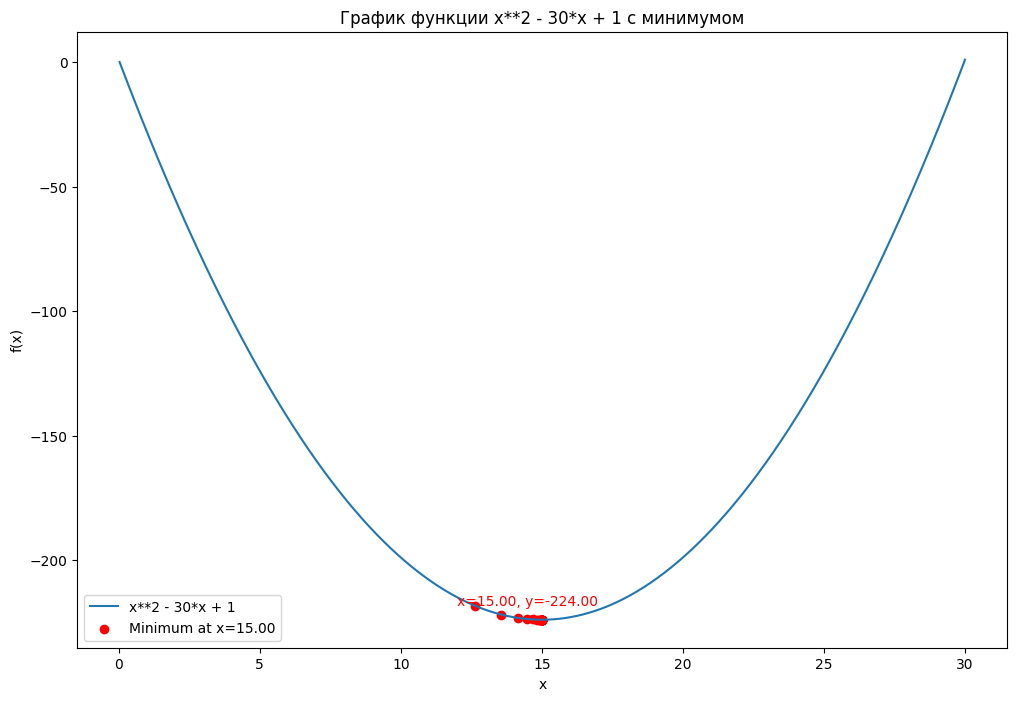

In [ ]:
x = sp.Symbol('x')
get_graph_gradient(x**2 - 30*x + 1, x, (0, 30), minimum_x, minimum_y, trace)

In [ ]:
x_start = np.random.uniform(-10, 10)
learning_rate = 0.1
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x = sp.Symbol('x')
f = -x**3 + 5*x - 7*x**2 + 17
f_num = sp.lambdify(x, f, 'numpy')

minimum_x, trace = gradient_descent(-x**3 + 5*x - 7*x**2 + 17, x, x_start, learning_rate, epsilon, num_iterations, delta)
minimum_x = float(minimum_x)
minimum_y = f_num(minimum_x)
print(f'x_start: {x_start}, learning_rate: {learning_rate}, minimum_x: {minimum_x}, minimum_y: {minimum_y}')

x_start: -8.296299306846366, learning_rate: 0.1, minimum_x: -5.000000505434947, minimum_y: -57.999999999997954


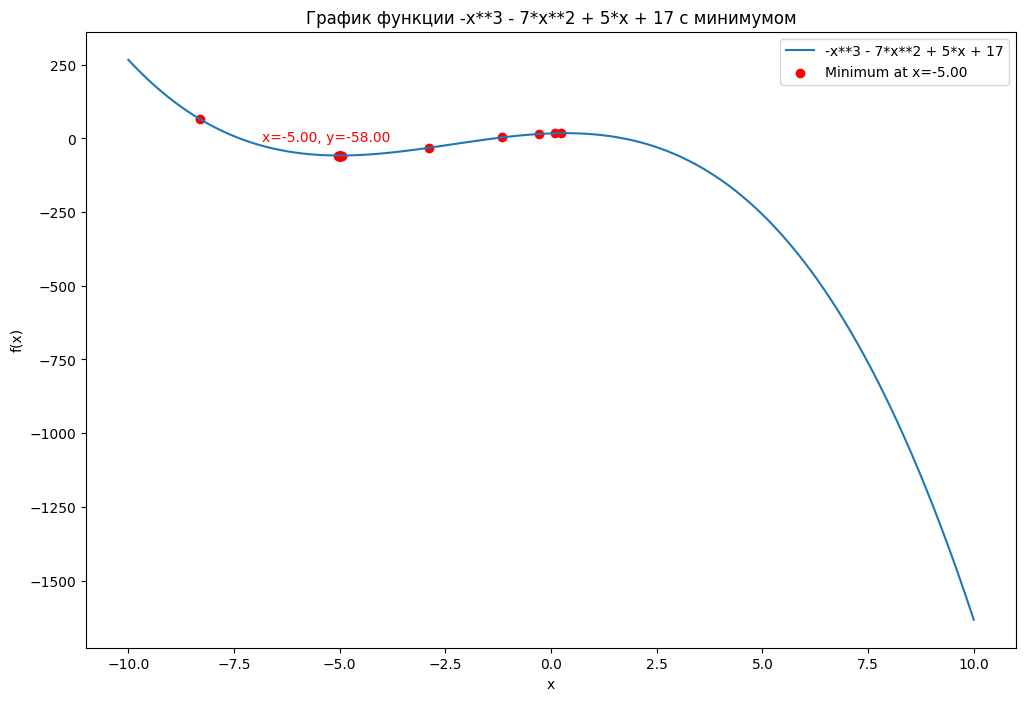

In [ ]:
x = sp.Symbol('x')
get_graph_gradient(-x**3 + 5*x - 7*x**2 + 17, x, (-10, 10), minimum_x, minimum_y, trace)

In [ ]:
x_start = np.random.uniform(-1, 2)
learning_rate = 0.002
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x = sp.Symbol('x')
f = x**2 - 1/x
f_num = sp.lambdify(x, f, 'numpy')

minimum_x, trace = gradient_descent(x**2 - 1/x, x, x_start, learning_rate, epsilon, num_iterations, delta)
minimum_x = float(minimum_x)
minimum_y = f_num(minimum_x)
print(f'x_start: {x_start}, learning_rate: {learning_rate}, minimum_x: {minimum_x}, minimum_y: {minimum_y}')

x_start: -0.9492830521029375, learning_rate: 0.002, minimum_x: -0.7937836387981354, minimum_y: 1.8898815955640829


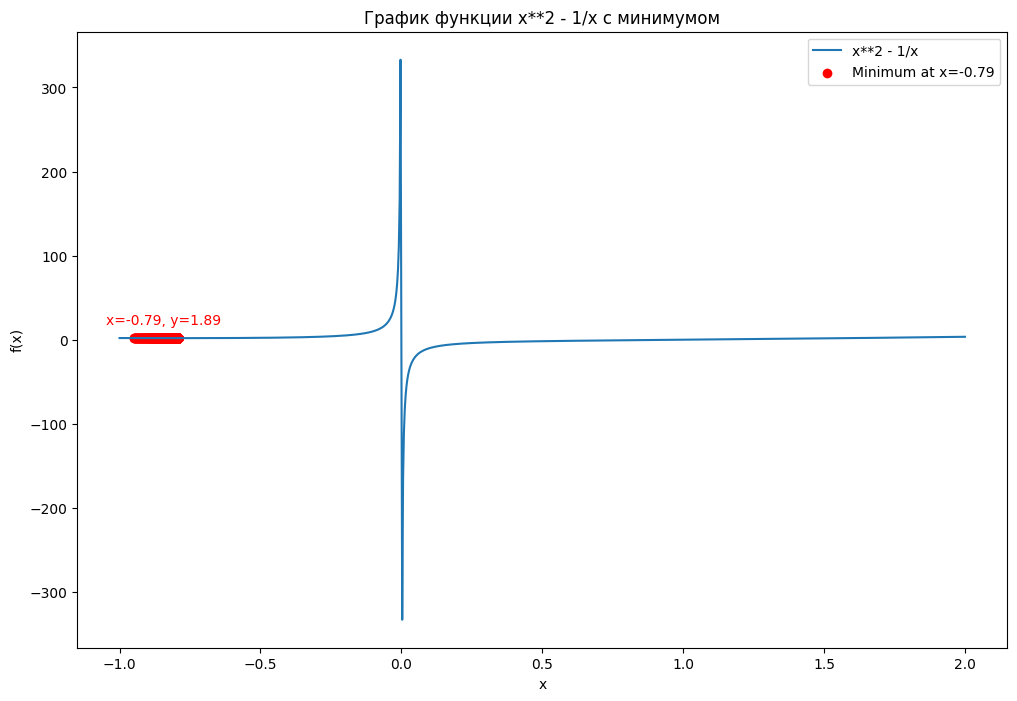

In [ ]:
x = sp.Symbol('x')
get_graph_gradient(x**2 - 1/x, x, (-1, 2), minimum_x, minimum_y, trace)

In [ ]:
x_start = np.random.uniform(-5, 5)
learning_rate = 0.00000001
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x = sp.Symbol('x')
f = 1/x**5 + x**17 + 8
f_num = sp.lambdify(x, f, 'numpy')

minimum_x, trace = gradient_descent(1/x**5 + x**17 + 8, x, x_start, learning_rate, epsilon, num_iterations, delta)
minimum_x = float(minimum_x)
minimum_y = f_num(minimum_x)
print(f'x_start: {x_start}, learning_rate: {learning_rate}, minimum_x: {minimum_x}, minimum_y: {minimum_y}')

x_start: 2.049634926116955, learning_rate: 1e-08, minimum_x: 1.4879379890228241, minimum_y: 867.0362057265062


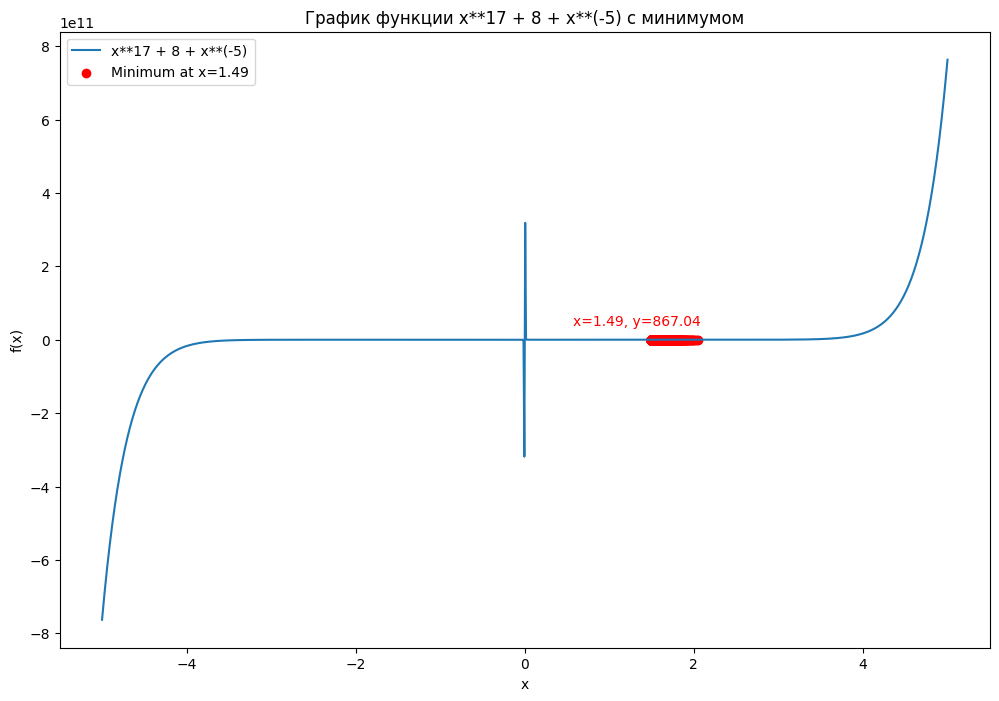

In [ ]:
x = sp.Symbol('x')
get_graph_gradient(1/x**5 + x**17 + 8, x, (-5, 5), minimum_x, minimum_y, trace)

## Задание 8 (1.5 балла)

Реализуйте [метод Ньютона](https://en.wikipedia.org/wiki/Newton%27s_method_in_optimization) (метод второго порядка) для поиска минимума функции.

Про метод ещё можно почитать [здесь](https://math.semestr.ru/optim/minimum.php).

In [ ]:
def method_newtona(f, x, x_start, epsilon, num_iterations, delta):
    x_curr = x_start
    df_x = sp.diff(f, x)
    d2f_x = sp.diff(df_x, x)
    trace = []
    trace.append(x_curr)

    for i in range(num_iterations):
        grad = df_x.subs(x, x_curr)
        hessian = d2f_x.subs(x, x_curr)

        if abs(hessian) < 1e-10:
            print("Метод Ньютона не работает, тк 2-я производная близка к 0.")
            return x_curr, trace

        if abs(grad) < delta:
            return x_curr, trace

        x_new = x_curr - grad / hessian
        trace.append(x_new)

        if abs(x_new - x_curr) < epsilon:
            return x_new, trace

        x_curr = x_new

    return x_curr, trace

## Задание 9 (0.5 балла)

Примените метод Ньютона для поиска минимума указанных функций (в ответе выведите подходящее значение начальной точки, график с найденным и подписанным значением минимума, как в задании 7).

In [ ]:
x_start = np.random.uniform(0, 30)
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x = sp.Symbol('x')
f = x**2 - 30*x + 1
f_num = sp.lambdify(x, f, 'numpy')

minimum_x_new, trace_new = method_newtona(x**2 - 30*x + 1, x, x_start, epsilon, num_iterations, delta)
minimum_y_new = f_num(minimum_x_new)

print(f'x_start: {x_start}, minimum_x: {minimum_x_new}, minimum_y: {minimum_y_new}')

x_start: 26.38836129544579, minimum_x: 15.0000000000000, minimum_y: -224.000000000000


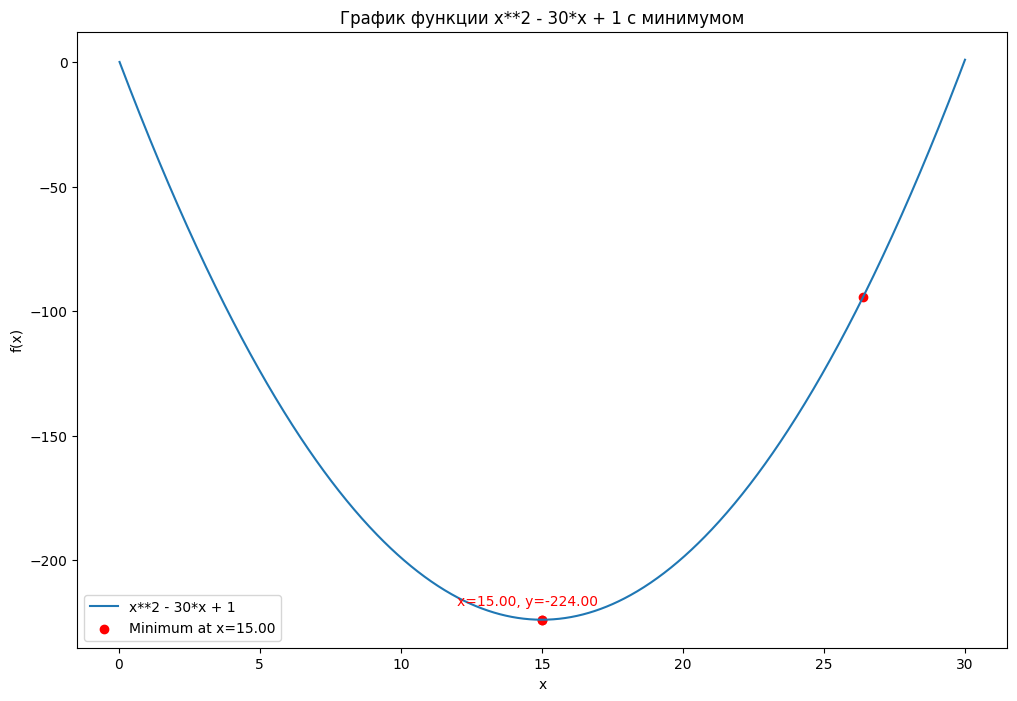

In [ ]:
x = sp.Symbol('x')
get_graph_gradient(x**2 - 30*x + 1, x, (0, 30), minimum_x_new, minimum_y_new, trace_new)

In [ ]:
x_start = np.random.uniform(-10, 10)
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x = sp.Symbol('x')
f = -x**3 + 5*x - 7*x**2 + 17
f_num = sp.lambdify(x, f, 'numpy')

minimum_x_new, trace_new = method_newtona(-x**3 + 5*x - 7*x**2 + 17, x, x_start, epsilon, num_iterations, delta)
minimum_y_new = f_num(minimum_x_new)

print(f'x_start: {x_start}, minimum_x: {minimum_x_new}, minimum_y: {minimum_y_new}')

x_start: -7.349635618922852, minimum_x: -5.00000003122783, minimum_y: -58.0000000000000


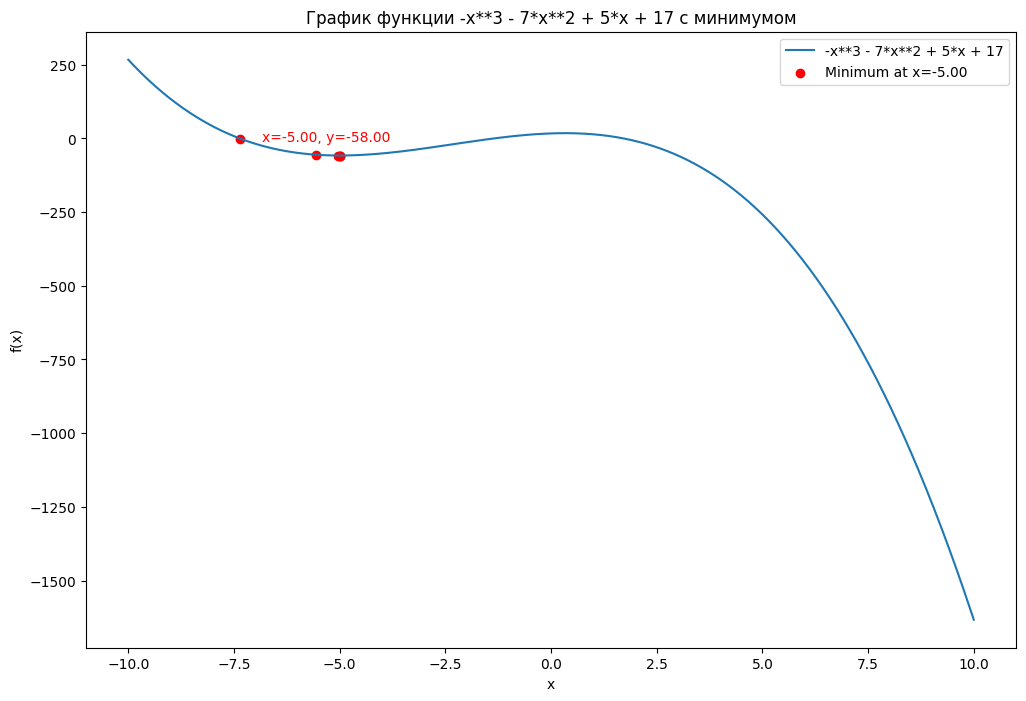

In [ ]:
x = sp.Symbol('x')
get_graph_gradient(-x**3 + 5*x - 7*x**2 + 17, x, (-10, 10), minimum_x_new, minimum_y_new, trace_new)

In [ ]:
x_start = np.random.uniform(-1, 2)
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x = sp.Symbol('x')
f = x**2 - 1/x
f_num = sp.lambdify(x, f, 'numpy')

minimum_x_new, trace_new = method_newtona(x**2 - 1/x, x, x_start, epsilon, num_iterations, delta)
minimum_y_new = f_num(minimum_x_new)

print(f'x_start: {x_start}, minimum_x: {minimum_x_new}, minimum_y: {minimum_y_new}')

x_start: -0.04866596599021711, minimum_x: -0.793700357722147, minimum_y: 1.88988157484239


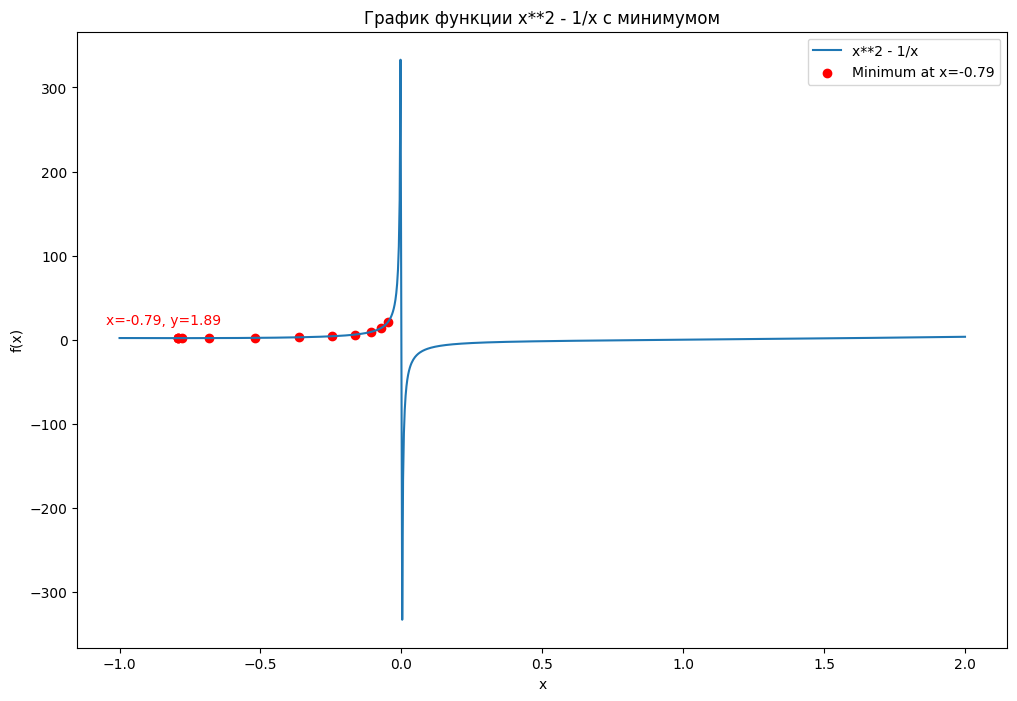

In [ ]:
x = sp.Symbol('x')
get_graph_gradient(x**2 - 1/x, x, (-1, 2), minimum_x_new, minimum_y_new, trace_new)

In [ ]:
x_start = np.random.uniform(-5, 5)
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x = sp.Symbol('x')
f = 1/x**5 + x**17 + 8
f_num = sp.lambdify(x, f, 'numpy')

minimum_x_new, trace_new = method_newtona(1/x**5 + x**17 + 8, x, x_start, epsilon, num_iterations, delta)
minimum_y_new = f_num(minimum_x_new)

print(f'x_start: {x_start}, minimum_x: {minimum_x_new}, minimum_y: {minimum_y_new}')

x_start: 0.33890751119635887, minimum_x: 0.945892686121980, minimum_y: 9.70908799027152


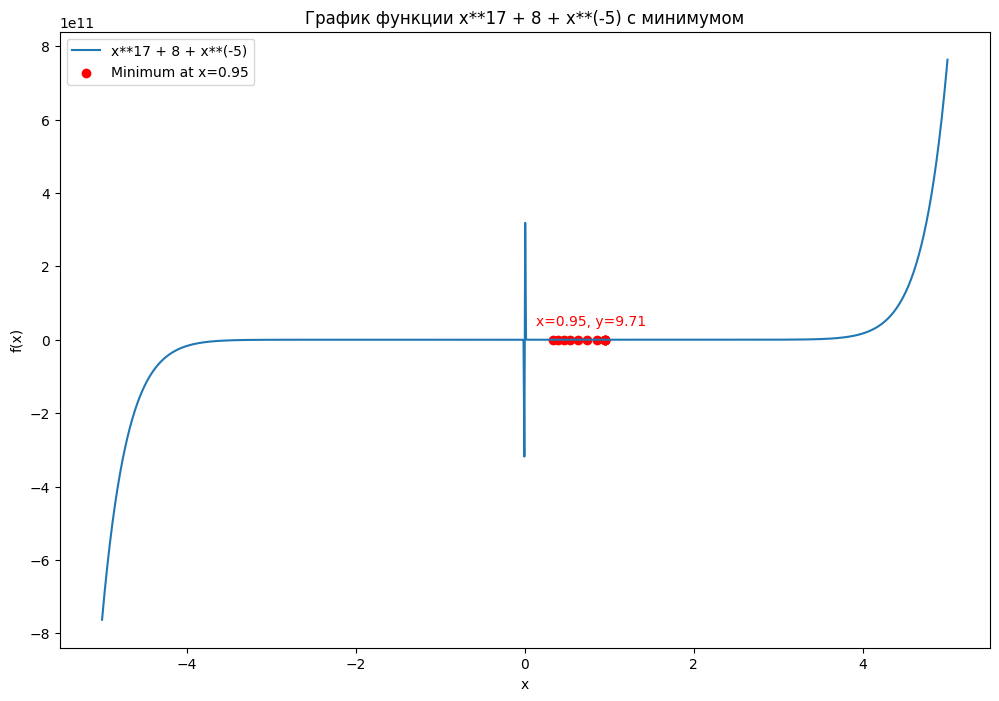

In [ ]:
x = sp.Symbol('x')
get_graph_gradient(1/x**5 + x**17 + 8, x, (-5, 5), minimum_x_new, minimum_y_new, trace_new)

## Задание 10 (1 балл)

Сравните скорость работы градиентного спуска и метода Ньютона при одинаковой точности решения $|x_{found}-x_{true}|<10^{-5}$:
* за сколько итераций каждый метод сходится (в среднем по всем функциям для правильно подобранных значений гиперпараметров)? Какой быстрее?
* какой метод дает более точный результат при фиксированном числе итераций $N=10$? (для ответа на этот вопрос добавьте в процедуру градиентного спуска возможность останавливаться при достижении некоторого количества итераций $N$)

## **Бонусная часть**

## Задание 11 (1 балл)

Реализуйте оптимизацию метода градиентного спуска - Momentum. Необходимые выкладки вы можете подсмотреть [здесь](https://education.yandex.ru/handbook/ml/article/optimizaciya-v-ml).

In [ ]:
def momentum(f, x, x_start, learning_rate, beta, epsilon, num_iterations, delta):
    x_curr = x_start
    df_x = sp.diff(f, x)
    a = 0
    trace = [x_curr]

    for i in range(num_iterations):
        grad = df_x.subs(x, x_curr)

        if abs(grad) < delta:
            return x_curr, trace

        velocity = beta * a - learning_rate * grad

        x_new = x_curr + velocity
        trace.append(x_new)

        if abs(x_new - x_curr) < epsilon:
            return x_new, trace

        x_curr = x_new

    return x_curr, trace

## Задание 12 (0.5 балла)

Проверьте, решает ли Momentum GD проблему поиска начального приближения для функций из задания 1?

In [ ]:
f = x**2 - 30*x + 1
x = sp.Symbol('x')
learning_rate = 0.1
m = 0.9
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x_start = np.random.uniform(0, 30)
x_true = 15

minimum_x, trace = momentum(x**2 - 30*x + 1, x, x_start, learning_rate, m, epsilon, num_iterations, delta)
error = abs(minimum_x - x_true)

In [ ]:
print(f'x_start: {x_start}, minimum_x: {minimum_x}, error: {error}')

x_start: 0.9159146308394184, minimum_x: 14.9999954735495, error: 0.00000452645051929323


In [ ]:
f = -x**3 + 5*x - 7*x**2 + 17
x = sp.Symbol('x')
learning_rate = 0.1
m = 0.9
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x_start = np.random.uniform(-10, 10)
x_true = -5

minimum_x, trace = momentum(f, x, x_start, learning_rate, m, epsilon, num_iterations, delta)
minimum_x = float(minimum_x)
error = abs(minimum_x - x_true)

print(f'x_start: {x_start}, minimum_x: {minimum_x}, error: {error}')

x_start: -3.6626182691960256, minimum_x: -5.000000480350014, error: 4.80350013987163e-07


In [ ]:
f = x**2 - 1/x
x = sp.Symbol('x')
learning_rate = 0.1
m = 0.9
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x_start = np.random.uniform(-10, 10)
x_true = -2**(2/3)/2

minimum_x, trace = momentum(x**2 - 1/x, x, x_start, learning_rate, m, epsilon, num_iterations, delta)
minimum_x = float(minimum_x)
error = abs(minimum_x - x_true)

print(f'x_start: {x_start}, minimum_x: {minimum_x}, error: {error}')

x_start: -7.2945993696415705, minimum_x: -0.7937012674593734, error: 7.414752737355812e-07


In [ ]:
f = 1/x**5 + x**17 + 8
x = sp.Symbol('x')
learning_rate = 0.1
m = 0.9
epsilon = 1e-6
delta = 1e-5
num_iterations = 1000
x_start = np.random.uniform(-5, 5)
x_true = -17**(21/22)*5**(1/22)/17

minimum_x, trace = momentum(1/x**5 + x**17 + 8, x, x_start, learning_rate, m, epsilon, num_iterations, delta)
minimum_x = float(minimum_x)
error = abs(minimum_x - x_true)

print(f'x_start: {x_start}, minimum_x: {minimum_x}, error: {error}')

x_start: -2.609753852624701, minimum_x: -inf, error: inf


Для последней функции моментум не решил задачу, сл-но он применим не ко всем функциям.